In [1]:
from pathlib import Path
import sys

code_dir = Path('/workspace/gdp-hmm-model')
sys.path.append(str(code_dir)) # Need to be string
sys.path.append(str(code_dir/'mednext'))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from nnunet_mednext import create_mednext_v1
import yaml
from pprint import pprint

from tqdm import tqdm
import numpy as np

In [3]:
%load_ext autoreload
%autoreload 2

import data_loader



In [4]:
cfig = yaml.load(open(code_dir / 'config_files/config.yaml'), Loader=yaml.FullLoader)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
model = create_mednext_v1( num_input_channels = cfig['model_params']['num_input_channels'],
  num_classes = cfig['model_params']['out_channels'],
  model_id = cfig['model_params']['model_id'],          # S, B, M and L are valid model ids
  kernel_size = cfig['model_params']['kernel_size'],   # 3x3x3 and 5x5x5 were tested in publication
  deep_supervision = cfig['model_params']['deep_supervision']
).to(device)

model.load_state_dict(torch.load('weights/candidate_2_ft_v3.2.pt'))

<All keys matched successfully>

In [6]:
from pathlib import Path
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Fixed length, random sampled
# extra param: size -> size of the dataset

class ChallengeData(Dataset):
    def __init__(self, data_dir, ids, size=None):
        super().__init__()
        self.data_dir = Path(data_dir)
        self.ids = ids
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.size = size if size is not None else len(ids)
        self._sample()

    def __len__(self):
        return self.size

    def _sample(self):
        if self.size < len(self.ids):
            self.current_ids = np.random.choice(self.ids, self.size, replace=False).tolist()
            print('Dataset resampled')
        else:
            self.current_ids = self.ids.copy()
            print('Dataset all samples used')

    def __getitem__(self, idx):
        npz_path = self.data_dir / f'{self.current_ids[idx]}.npz'

        data_dict = dict(np.load(npz_path))

        # Unsqueeze the 1st dim: x -> (8, 96, 128, 144)
        x = torch.from_numpy(data_dict['data'])[0].to(self.device)
        y = torch.from_numpy(data_dict['label'])[0].to(self.device)

        # Mask, derived from x
        body_mask = x[3:4,...].bool()
        outbody_mask = ~body_mask
        ptv_mask = x[1:2, ...].bool()
        near_mask = torch.logical_and(~ptv_mask, body_mask)

        if idx==self.size-1: self._sample()
            
        return x, y, body_mask, outbody_mask, ptv_mask, near_mask



In [7]:
from sklearn.model_selection import train_test_split

others, test_ids = train_test_split(range(2728), test_size=0.3, random_state=1234)
train_ids, val_ids = train_test_split(others, test_size=0.3, random_state=1234)

In [8]:
batch_size = 4

data_tr = ChallengeData('/workspace/data/train_data_dict', train_ids, size=100)
loader_tr = DataLoader(data_tr, batch_size=batch_size, shuffle=False)

data_vl = ChallengeData('/workspace/data/train_data_dict', val_ids, size=20)
loader_vl = DataLoader(data_vl, batch_size=batch_size, shuffle=False)

data_ts = ChallengeData('/workspace/data/train_data_dict', test_ids)
loader_ts = DataLoader(data_ts, batch_size=batch_size, shuffle=False)


Dataset resampled
Dataset resampled
Dataset all samples used


In [32]:
def cal_error(pred, gt, body):
    isodose_5Gy_mask = ((gt > 5) | (pred > 5)) & (body > 0)
    isodose_ref_5Gy_mask = (gt > 5) & (body > 0)
    diff = gt - pred
    error = torch.sum(torch.abs(diff)[isodose_5Gy_mask > 0]) / torch.sum(isodose_ref_5Gy_mask)
    return error

def custom_loss(outputs, y, body_mask, outbody_mask, ptv_mask, near_mask, _id):
    if _id == 1:
        loss = criterion(outputs, y)
    if _id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
    if _id == 3:
        loss = criterion(outputs[body_mask], y[body_mask]) + 5 * criterion(outputs[near_mask], y[near_mask])
    if _id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

    return loss

def iso_5_dice(pred, gt, body):
    iso_mask = ((gt > 5) | (pred > 5)) & (body > 0)
    iso_mask_gt = (gt > 5) & (body > 0)
    return 2*(iso_mask*iso_mask_gt).sum() / (iso_mask.sum() + iso_mask_gt.sum())

def img_grad(img):
    return img[..., :-1, :-1, :-1] - img[..., 1:, 1:, 1:]

def cal_grad_loss(pred, y, mask):
    _mask = mask[..., :-1, :-1, :-1]
    return criterion(img_grad(pred)[_mask], img_grad(y)[_mask])
    

In [45]:
class SmoothModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv3d(1, 4, kernel_size=5, padding='same', bias=False)
        self.conv2 = torch.nn.Conv3d(4, 1, kernel_size=5, padding='same', bias=False)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return x

s_model = SmoothModel().to(device)
model.eval()
s_model.train()

SmoothModel(
  (conv1): Conv3d(1, 4, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same, bias=False)
  (conv2): Conv3d(4, 1, kernel_size=(5, 5, 5), stride=(1, 1, 1), padding=same, bias=False)
)

In [60]:
optimizer = optim.Adam(s_model.parameters(), lr=1e-4)
criterion = nn.L1Loss()
epochs = 10

In [47]:
loss_id = 5

In [82]:
for epoch in range(1):
    
    pbar = tqdm(loader_tr, f'Epoch {epoch}')
    
    train_loss = []
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask in pbar:
        
      # Forward pass
      with torch.no_grad():
          x_ = model(x)
      
      outputs = s_model(x_)

      if loss_id == 1:
        loss = criterion(outputs, y)
      if loss_id == 2:
        loss = criterion(outputs[body_mask], y[body_mask])
      if loss_id == 3:
        loss = 1 * criterion(outputs[body_mask], y[body_mask]) + \
               10 * criterion(outputs[near_mask], y[near_mask]) + \
               cal_error(outputs, y, body_mask) 
               # 30*iso_5_dice(outputs, y, body_mask) + \
              # 10 * criterion(outputs[outbody_mask], y[outbody_mask])
    
      if loss_id == 4:
        loss = cal_error(outputs, y, body_mask) + criterion(outputs, y) + torch.max(outputs[outbody_mask])

      if loss_id == 5:
        loss = 1 * cal_error(outputs, y, body_mask)  + \
               50 * cal_grad_loss(outputs, y, body_mask)
    
      # Backward pass and optimization
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
    
      train_loss.append(loss.detach().cpu().item())
      pbar.set_postfix_str(f'Loss: {loss.item():.3f}')
    
    val_loss = []
    model.eval()
    for x, y, body_mask, outbody_mask, ptv_mask, near_mask in loader_vl:
        with torch.no_grad():
            x_ = model(x)
            outputs = s_model(x_)
            loss = cal_error(outputs, y, body_mask)
            val_loss.append(loss.detach().cpu().item())
    
    print(f'Train loss: {np.mean(train_loss):.3f} ({np.std(train_loss):.3f}) '+ \
          f'Val loss: {np.mean(val_loss):.3f} ({np.std(val_loss):.3f})')


Epoch 0:  96%|█████████▌| 24/25 [00:13<00:00,  1.75it/s, Loss: 3.179]

Dataset resampled


Epoch 0: 100%|██████████| 25/25 [00:14<00:00,  1.75it/s, Loss: 3.673]


Dataset resampled
Train loss: 4.757 (1.271) Val loss: 0.323 (0.059)


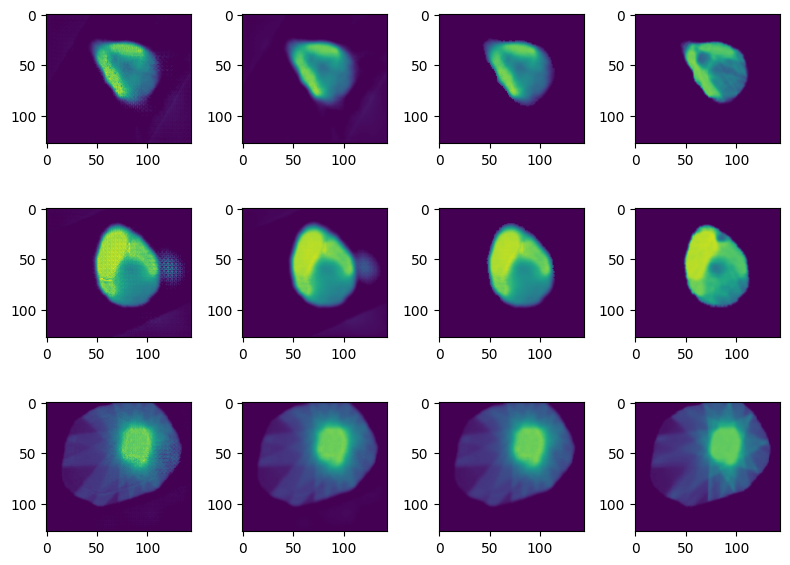

In [83]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 4, figsize=(8, 6))

out_masked = outputs.clone()
out_masked[body_mask==False] = 0

for i in range(3):
    ax[i,0].imshow(x_[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,1].imshow(outputs[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,2].imshow(out_masked[i,0,50].detach().cpu(), vmin=0, vmax=8)
    ax[i,3].imshow(y.cpu()[i,0,50], vmin=0, vmax=8)
plt.tight_layout()

In [84]:
ts_loss = []
model.eval()

pbar = tqdm(loader_ts)
for x, y, body_mask, outbody_mask, ptv_mask, near_mask in pbar:
    with torch.no_grad():
        x_ = model(x)
        outputs = s_model(x_)
        # loss = criterion(outputs, y)
        
        loss = cal_error(outputs, y, body_mask)
        ts_loss.append(loss.detach().cpu().item())
        pbar.set_postfix_str(f'Test loss: {np.mean(ts_loss):.3f}')



100%|██████████| 205/205 [01:51<00:00,  1.83it/s, Test loss: 0.361]

Dataset all samples used


In [75]:
torch.save(model.state_dict(), 'weights/smooth_v1.pt') # Test loss: 0.360

In [67]:
model.load_state_dict(torch.load('weights/smooth_v1.pt'))

<All keys matched successfully>